# 数据读取

In [19]:
import torch

test_path = "/home/charles/HZU/Data_processed/HSML/KAIST/current&temp_raw_wl_5000/test/pyg/graph.pt"
train_path = "/home/charles/HZU/Data_processed/HSML/KAIST/current&temp_raw_wl_5000/train/pyg/train_graph_with_labelmask.pt"
val_path   = "/home/charles/HZU/Data_processed/HSML/KAIST/current&temp_raw_wl_5000/val/pyg/graph.pt"

test_graph  = torch.load(test_path, map_location="cpu")
train_graph = torch.load(train_path, map_location="cpu")
val_graph   = torch.load(val_path, map_location="cpu")

def inspect_graph(g, name):
    print(f"\n===== {name} =====")
    print(g)
    print("num_nodes:", g.num_nodes)
    print("num_edges:", g.edge_index.size(1))
    print("node features x:", None if g.x is None else g.x.shape)
    print("edge_index:", g.edge_index.shape)
    if hasattr(g, "y"):
        print("labels y:", g.y.shape)
    if hasattr(g, "train_mask"):
        print("train_mask:", g.train_mask.shape)
    if hasattr(g, "val_mask"):
        print("val_mask:", g.val_mask.shape)
    if hasattr(g, "test_mask"):
        print("test_mask:", g.test_mask.shape)

inspect_graph(train_graph, "TRAIN")
inspect_graph(val_graph, "VAL")
inspect_graph(test_graph, "TEST")



===== TRAIN =====
Data(x=[45000, 5], edge_index=[2, 900000], y=[45000], train_withlabel_mask=[45000], train_nolabel_mask=[45000])
num_nodes: 45000
num_edges: 900000
node features x: torch.Size([45000, 5])
edge_index: torch.Size([2, 900000])
labels y: torch.Size([45000])

===== VAL =====
Data(x=[7500, 5], edge_index=[2, 150000], y=[7500])
num_nodes: 7500
num_edges: 150000
node features x: torch.Size([7500, 5])
edge_index: torch.Size([2, 150000])
labels y: torch.Size([7500])

===== TEST =====
Data(x=[22500, 5], edge_index=[2, 450000], y=[22500])
num_nodes: 22500
num_edges: 450000
node features x: torch.Size([22500, 5])
edge_index: torch.Size([2, 450000])
labels y: torch.Size([22500])


/tmp/ipykernel_12903/1019197295.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  test_graph  = torch.load(test_path, map_location="cpu")
/tmp/ipykernel_12903/1019197295.p

## 数据选择，BPFO数据只有一路电流，先用全部有的数据进行分类，用于后期缺失值补全后的效果做对比

In [20]:
# import torch

# def check_nan_inf(x):
#     return {
#         "has_nan": torch.isnan(x).any().item(),
#         "has_inf": torch.isinf(x).any().item()
#     }

# def process_x(data, name):
#     print(f"\n===== {name} =====")

#     assert data.x is not None, f"{name}: data.x is None"

#     # ================= 1️⃣ 删除前检查 =================
#     print("Original data.x shape:", data.x.shape)
#     before_status = check_nan_inf(data.x)
#     print("Before drop - Has NaN:", before_status["has_nan"])
#     print("Before drop - Has Inf:", before_status["has_inf"])

#     # ================= 2️⃣ 删除最后两列 =================
#     if data.x.size(1) < 3:
#         raise ValueError(f"{name}: data.x has less than 3 features, cannot drop last two columns")

#     data.x = data.x[:, :-2]

#     # ================= 3️⃣ 删除后检查 =================
#     print("After drop shape:", data.x.shape)
#     after_status = check_nan_inf(data.x)
#     print("After drop - Has NaN:", after_status["has_nan"])
#     print("After drop - Has Inf:", after_status["has_inf"])

#     # ================= 4️⃣ 结论提示 =================
#     if before_status["has_nan"] or before_status["has_inf"]:
#         print("⚠️ WARNING: Invalid values already exist BEFORE feature drop")

#     if after_status["has_nan"] or after_status["has_inf"]:
#         print("⚠️ WARNING: Invalid values remain AFTER feature drop")

#     if not any(before_status.values()) and not any(after_status.values()):
#         print("✅ data.x is clean before and after drop")

# # ===== 执行 =====
# process_x(train_graph, "TRAIN")
# process_x(val_graph,   "VAL")
# process_x(test_graph,  "TEST")


## 将含有nan的数据删掉

In [21]:
import torch

def clean_graph_nan_inf(data, name):
    print(f"\n===== CLEAN {name} =====")

    assert data.x is not None, f"{name}: data.x is None"

    x = data.x

    # ================= 1️⃣ 找到非法样本（行级） =================
    nan_mask = torch.isnan(x).any(dim=1)
    inf_mask = torch.isinf(x).any(dim=1)
    invalid_mask = nan_mask | inf_mask

    num_invalid = invalid_mask.sum().item()
    num_total = x.size(0)

    print(f"Total nodes      : {num_total}")
    print(f"Invalid nodes    : {num_invalid}")
    print(f"Valid nodes kept : {num_total - num_invalid}")

    if num_invalid == 0:
        print("✅ No NaN / Inf samples found")
        return data

    # ================= 2️⃣ 构造保留 mask =================
    keep_mask = ~invalid_mask

    # ================= 3️⃣ 过滤 x / y =================
    data.x = data.x[keep_mask]

    if hasattr(data, "y") and data.y is not None:
        data.y = data.y[keep_mask]

    # ================= 4️⃣ 过滤 edge_index（非常关键） =================
    if hasattr(data, "edge_index") and data.edge_index is not None:
        edge_index = data.edge_index

        # old_idx -> new_idx 映射
        old_to_new = torch.full(
            (keep_mask.size(0),),
            -1,
            dtype=torch.long,
            device=keep_mask.device
        )
        old_to_new[keep_mask] = torch.arange(
            keep_mask.sum(),
            device=keep_mask.device
        )

        src, dst = edge_index
        edge_keep = keep_mask[src] & keep_mask[dst]

        data.edge_index = torch.stack([
            old_to_new[src[edge_keep]],
            old_to_new[dst[edge_keep]]
        ], dim=0)

    # ================= 5️⃣ 同步所有 mask（train / val / test） =================
    for attr in [
        "train_mask",
        "val_mask",
        "test_mask",
        "train_withlabel_mask",
        "train_nolabel_mask"
    ]:
        if hasattr(data, attr):
            setattr(data, attr, getattr(data, attr)[keep_mask])

    print("✅ Graph cleaned and overwritten")

    return data


# ======================= 执行（覆盖原变量） =======================
train_graph = clean_graph_nan_inf(train_graph, "TRAIN")
val_graph   = clean_graph_nan_inf(val_graph,   "VAL")
test_graph  = clean_graph_nan_inf(test_graph,  "TEST")



===== CLEAN TRAIN =====
Total nodes      : 45000
Invalid nodes    : 8979
Valid nodes kept : 36021
✅ Graph cleaned and overwritten

===== CLEAN VAL =====
Total nodes      : 7500
Invalid nodes    : 1523
Valid nodes kept : 5977
✅ Graph cleaned and overwritten

===== CLEAN TEST =====
Total nodes      : 22500
Invalid nodes    : 4498
Valid nodes kept : 18002
✅ Graph cleaned and overwritten


## 小图构造

In [22]:
# ===================== 0️⃣ 依赖 =====================
import torch
from torch.utils.data import Dataset, DataLoader

# ===================== 1️⃣ NodeDataset（不区分标签，只打包节点） =====================
class NodeDataset(Dataset):
    """
    Node-level Dataset（统一打包）：
    - 不区分有/无标签
    - mask 保留在 data 中，训练阶段再使用
    """
    def __init__(self, data):
        self.data = data
        self.node_idx = torch.arange(data.num_nodes)
        print(f"✔ Using ALL nodes, num_nodes = {data.num_nodes}")

    def __len__(self):
        return self.node_idx.size(0)

    def __getitem__(self, idx):
        return self.node_idx[idx]


# ===================== 2️⃣ Dataset 构建 =====================
train_dataset = NodeDataset(train_graph)
val_dataset   = NodeDataset(val_graph)
test_dataset  = NodeDataset(test_graph)


# ===================== 3️⃣ DataLoader（load 打包，不拆 mask） =====================
batch_size = 512*4   # ⭐ 4GB 显存建议 256 / 512

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


# ===================== 4️⃣ 快速自检（确认打包正确） =====================
print("\n===== Loader Sanity Check =====")

batch_nodes = next(iter(train_loader))
print("[TRAIN]")
print("Batch size:", batch_nodes.size(0))
print("Min node id:", batch_nodes.min().item())
print("Max node id:", batch_nodes.max().item())

batch_nodes = next(iter(val_loader))
print("\n[VAL]")
print("Batch size:", batch_nodes.size(0))
print("Min node id:", batch_nodes.min().item())
print("Max node id:", batch_nodes.max().item())

batch_nodes = next(iter(test_loader))
print("\n[TEST]")
print("Batch size:", batch_nodes.size(0))
print("Min node id:", batch_nodes.min().item())
print("Max node id:", batch_nodes.max().item())

print("\n✅ Unified Node-level DataLoader setup finished.")


✔ Using ALL nodes, num_nodes = 36021
✔ Using ALL nodes, num_nodes = 5977
✔ Using ALL nodes, num_nodes = 18002

===== Loader Sanity Check =====
[TRAIN]
Batch size: 2048
Min node id: 3
Max node id: 35939

[VAL]
Batch size: 2048
Min node id: 0
Max node id: 2047

[TEST]
Batch size: 2048
Min node id: 0
Max node id: 2047

✅ Unified Node-level DataLoader setup finished.


# 模型初始化

In [23]:
import sys
import os

# ===== 添加项目根目录到 PYTHONPATH =====
PROJECT_ROOT = "/home/charles/HZU/Industrial_Software_Testing/Industrial_Software_Testing/High_similar_ML/HS_ML_v1"
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("✔ Project root added to sys.path")


import torch
from src.model import GraphContrastiveLearner

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===== 从图中读取真实维度 =====
data = train_graph   # 你前面 torch.load 读出来的
in_dim = data.x.size(1)

# ===== 模型超参数=====
hidden_dim = 256
out_dim    = 128
proj_dim   = 128
tau        = 0.5

# ===== 初始化对比学习模型 =====
model = GraphContrastiveLearner(
    in_dim=in_dim,
    hidden_dim=hidden_dim,
    out_dim=out_dim,
    proj_dim=proj_dim,
    tau=tau
).to(device)

print(model)


✔ Project root added to sys.path
GraphContrastiveLearner(
  (encoder): GCNEncoder(
    (conv1): SAGEConv(5, 256, aggr=mean)
    (conv2): SAGEConv(256, 128, aggr=mean)
  )
  (projector): MLPHead(
    (fc1): Linear(in_features=128, out_features=128, bias=True)
    (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (act): GELU(approximate='none')
    (fc2): Linear(in_features=128, out_features=128, bias=True)
  )
)


# 上游GCL训练

In [24]:
from torch_geometric.utils import subgraph
from torch_geometric.data import Data
# ===== 添加项目根目录到 PYTHONPATH =====
PROJECT_ROOT = "/home/charles/HZU/Industrial_Software_Testing/Industrial_Software_Testing/High_similar_ML/HS_ML_v1"
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("✔ Project root added to sys.path")
from src.model import augment_graph

def train_one_epoch_with_loader(
    model,
    full_graph,
    loader,
    optimizer,
    feature_drop=0.1,
    edge_drop=0.1,
    noise_std=0.01
):
    model.train()
    device = next(model.parameters()).device

    total_loss = 0.0
    num_batches = 0

    for batch_nodes in loader:
        # ===================== 1️⃣ 子图构建（CPU） =====================
        batch_nodes_cpu = batch_nodes.cpu()

        edge_index, _ = subgraph(
            batch_nodes_cpu,
            full_graph.edge_index,     # CPU
            relabel_nodes=True,
            num_nodes=full_graph.num_nodes
        )

        x = full_graph.x[batch_nodes_cpu]

        # ===================== 2️⃣ 搬到 GPU =====================
        sub_data = Data(
            x=x.to(device),
            edge_index=edge_index.to(device)
        )

        # ===================== 3️⃣ 两个增强视图 =====================
        view1 = augment_graph(
            sub_data,
            feature_drop_prob=feature_drop,
            edge_drop_prob=edge_drop,
            noise_std=noise_std
        )

        view2 = augment_graph(
            sub_data,
            feature_drop_prob=feature_drop,
            edge_drop_prob=edge_drop,
            noise_std=noise_std
        )

        # ===================== 4️⃣ 对比损失 =====================
        loss = model.compute_loss(
            view1.x, view1.edge_index,
            view2.x, view2.edge_index
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

    return total_loss / max(num_batches, 1)


✔ Project root added to sys.path


In [25]:
import torch

# ===== 自定义保存路径 =====
save_dir = "/home/charles/HZU/Industrial_Software_Testing/Industrial_Software_Testing/High_similar_ML/baseline/only_c&t_only_GCL/model_save/ignore_nan"  
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "contrastive_model.pt")

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

num_epochs = 200
log_interval = 10

for epoch in range(1, num_epochs + 1):
    loss = train_one_epoch_with_loader(
        model=model,
        full_graph=train_graph,   # ⭐ 整图
        loader=train_loader,      # ⭐ 统一 load
        optimizer=optimizer,
        feature_drop=0.1,
        edge_drop=0.1,
        noise_std=0.01
    )

    if epoch == 1 or epoch % log_interval == 0:
        print(f"[Epoch {epoch:03d}] Contrastive Loss = {loss:.4f}")

print("✅ Contrastive training (loader-based) finished.")

# ===== 保存模型 =====
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "num_epochs": num_epochs
}, save_path)

print(f"✅ Contrastive training finished.")
print(f"💾 Model saved to: {save_path}")


[Epoch 001] Contrastive Loss = 32.5677
[Epoch 010] Contrastive Loss = 30.8422
[Epoch 020] Contrastive Loss = 30.0348
[Epoch 030] Contrastive Loss = 29.3892
[Epoch 040] Contrastive Loss = 29.0041
[Epoch 050] Contrastive Loss = 28.8219
[Epoch 060] Contrastive Loss = 28.5848
[Epoch 070] Contrastive Loss = 28.4857
[Epoch 080] Contrastive Loss = 28.3349
[Epoch 090] Contrastive Loss = 28.2436
[Epoch 100] Contrastive Loss = 28.0098
[Epoch 110] Contrastive Loss = 27.8961
[Epoch 120] Contrastive Loss = 27.7884
[Epoch 130] Contrastive Loss = 27.7392
[Epoch 140] Contrastive Loss = 27.5990
[Epoch 150] Contrastive Loss = 27.5527
[Epoch 160] Contrastive Loss = 27.4416
[Epoch 170] Contrastive Loss = 27.3847
[Epoch 180] Contrastive Loss = 27.3684
[Epoch 190] Contrastive Loss = 27.2823
[Epoch 200] Contrastive Loss = 27.2885
✅ Contrastive training (loader-based) finished.
✅ Contrastive training finished.
💾 Model saved to: /home/charles/HZU/Industrial_Software_Testing/Industrial_Software_Testing/High_sim

# 上游GCL效果可视化

✅ Model loaded from: /home/charles/HZU/Industrial_Software_Testing/Industrial_Software_Testing/High_similar_ML/baseline/only_c&t_only_GCL/model_save/ignore_nan/contrastive_model.pt
Embedding shape: (36021, 128)
Labels shape: (36021,)


/tmp/ipykernel_12903/4128696926.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=device)


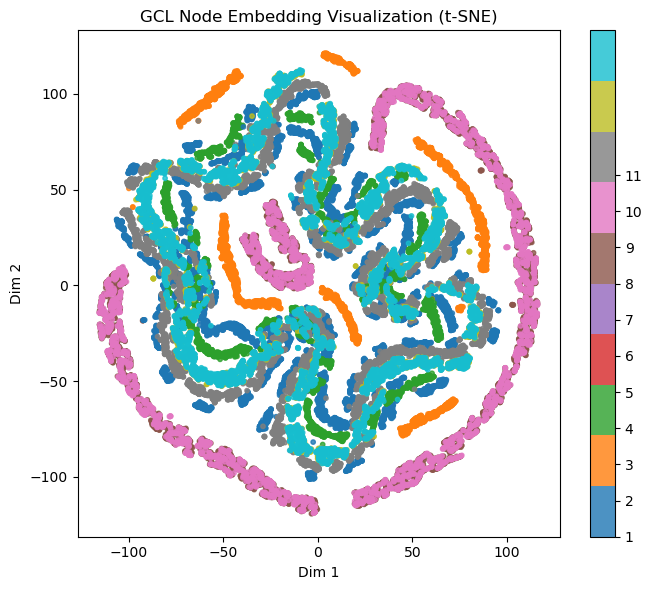

In [26]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# ================= 1️⃣ 读取模型 =================
ckpt_path = "/home/charles/HZU/Industrial_Software_Testing/Industrial_Software_Testing/High_similar_ML/baseline/only_c&t_only_GCL/model_save/ignore_nan/contrastive_model.pt"

device = next(model.parameters()).device
ckpt = torch.load(ckpt_path, map_location=device)

model.load_state_dict(ckpt["model_state_dict"])
model.eval()

print("✅ Model loaded from:", ckpt_path)

# ================= 2️⃣ 提取节点嵌入 =================
with torch.no_grad():
    z = model.encoder(
        train_graph.x.to(device),
        train_graph.edge_index.to(device)
    )

z = z.cpu().numpy()
y = train_graph.y.cpu().numpy()

print("Embedding shape:", z.shape)
print("Labels shape:", y.shape)

# ================= 3️⃣ t-SNE 降维（修正版） =================
tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    random_state=42
)

z_2d = tsne.fit_transform(z)

# ================= 4️⃣ 按标签可视化 =================
plt.figure(figsize=(7, 6))

num_classes = len(np.unique(y))
scatter = plt.scatter(
    z_2d[:, 0],
    z_2d[:, 1],
    c=y,
    cmap="tab10",
    s=10,
    alpha=0.8
)

plt.colorbar(scatter, ticks=range(num_classes))
plt.title("GCL Node Embedding Visualization (t-SNE)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.tight_layout()
plt.show()


# 下游训练

/tmp/ipykernel_12903/3958034763.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(GCL_CKPT_PATH, map_location=device)


[Epoch 001] Loss: 4.6401 | Train Acc: 0.0000 | Val Acc: 0.0 | Test Acc: 0.0
[Epoch 010] Loss: 2.6142 | Train Acc: 0.0867 | Val Acc: 0.07712899148464203 | Test Acc: 0.08915676176548004
[Epoch 020] Loss: 2.5043 | Train Acc: 0.0860 | Val Acc: 0.08449054509401321 | Test Acc: 0.08160204440355301
[Epoch 030] Loss: 2.4782 | Train Acc: 0.0927 | Val Acc: 0.09436171501874924 | Test Acc: 0.09565603733062744
[Epoch 040] Loss: 2.4511 | Train Acc: 0.1331 | Val Acc: 0.13116948306560516 | Test Acc: 0.1328185796737671
[Epoch 050] Loss: 2.4365 | Train Acc: 0.1329 | Val Acc: 0.13401371240615845 | Test Acc: 0.13192978501319885
[Epoch 060] Loss: 2.4194 | Train Acc: 0.1425 | Val Acc: 0.15024259686470032 | Test Acc: 0.14792799949645996
[Epoch 070] Loss: 2.3983 | Train Acc: 0.1615 | Val Acc: 0.1673080176115036 | Test Acc: 0.16714809834957123
[Epoch 080] Loss: 2.3707 | Train Acc: 0.1815 | Val Acc: 0.18705035746097565 | Test Acc: 0.18314631283283234
[Epoch 090] Loss: 2.3338 | Train Acc: 0.1926 | Val Acc: 0.1915

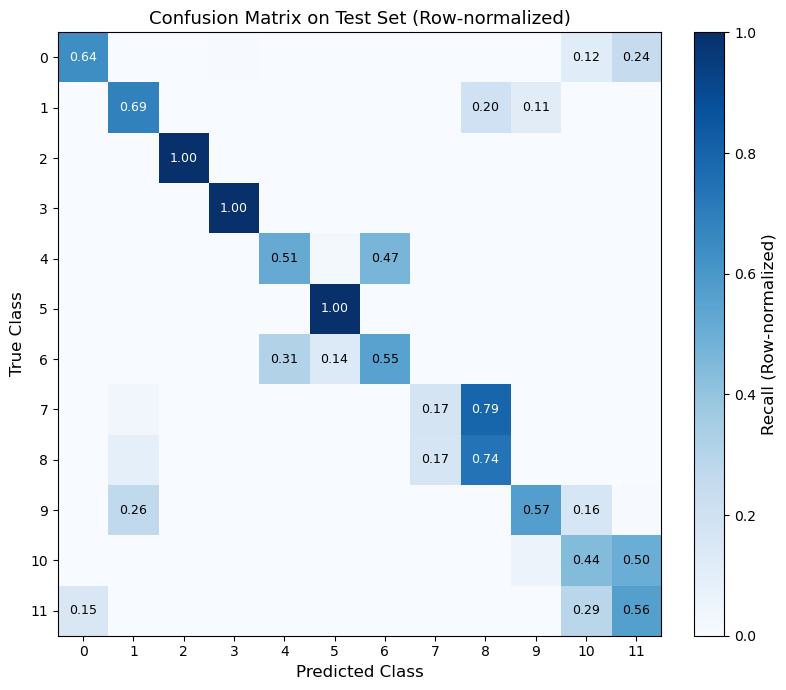

In [27]:
# ======================= 0️⃣ 基础导入 =======================
import sys
import torch
import torch.optim as optim

# ======================= 1️⃣ 导入 model.py =======================
MODEL_PATH = "/home/charles/HZU/Industrial_Software_Testing/Industrial_Software_Testing/High_similar_ML/baseline/only_c&t_only_GCL/src"
sys.path.append(MODEL_PATH)

from model import GraphContrastiveLearner, DownstreamClassifier

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ======================= 2️⃣ 图数据 =======================
train_graph = train_graph.to(device)
val_graph   = val_graph.to(device)
test_graph  = test_graph.to(device)

# ======================= 3️⃣ 加载 GCL encoder =======================
GCL_CKPT_PATH = (
    "/home/charles/HZU/Industrial_Software_Testing/"
    "Industrial_Software_Testing/High_similar_ML/"
    "baseline/only_c&t_only_GCL/model_save/ignore_nan/contrastive_model.pt"
)

gcl = GraphContrastiveLearner(
    in_dim=train_graph.num_features,
    hidden_dim=128,
    out_dim=128,
    proj_dim=64
).to(device)

ckpt = torch.load(GCL_CKPT_PATH, map_location=device)
gcl.load_state_dict(ckpt, strict=False)
gcl.eval()

# ⭐ 冻结 encoder
for p in gcl.encoder.parameters():
    p.requires_grad = False

# ======================= 4️⃣ 下游分类器 =======================
num_classes = int(train_graph.y.max().item() + 1)

classifier = DownstreamClassifier(
    in_dim=128,
    num_classes=num_classes,
    hidden_dim=128
).to(device)

optimizer = optim.Adam(
    classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

# ======================= 5️⃣ 训练函数（只用 train_graph） =======================
def train_one_epoch():
    classifier.train()
    optimizer.zero_grad()

    h, _ = gcl(train_graph.x, train_graph.edge_index)

    loss = classifier.compute_loss(
        h=h,
        y=train_graph.y,
        mask=train_graph.train_withlabel_mask  # ⭐ 唯一监督来源
    )

    loss.backward()
    optimizer.step()
    return loss.item()

# ======================= 6️⃣ 评估函数（自动适配有没有 mask） =======================
@torch.no_grad()
def evaluate(graph):
    classifier.eval()
    h, _ = gcl(graph.x, graph.edge_index)
    logits = classifier(h)
    pred = logits.argmax(dim=1)

    # ① 有 train_withlabel_mask → 只评标注节点
    if hasattr(graph, "train_withlabel_mask"):
        mask = graph.train_withlabel_mask
        acc = (pred[mask] == graph.y[mask]).float().mean().item()
        return acc

    # ② 没有 mask，但有 y → 全节点评估（谨慎解释）
    elif hasattr(graph, "y") and graph.y is not None:
        acc = (pred == graph.y).float().mean().item()
        return acc

    # ③ 什么都没有 → 不评
    else:
        return None

# ======================= 7️⃣ 正式训练 =======================
EPOCHS = 500
best_train_acc = 0.0

SAVE_PATH = (
    "/home/charles/HZU/Industrial_Software_Testing/"
    "Industrial_Software_Testing/High_similar_ML/"
    "baseline/only_c&t_only_GCL/model_save/ignore_nan/downstream_best.pt"
)

for epoch in range(1, EPOCHS + 1):
    loss = train_one_epoch()

    train_acc = evaluate(train_graph)
    val_acc   = evaluate(val_graph)
    test_acc  = evaluate(test_graph)

    if train_acc is not None and train_acc > best_train_acc:
        best_train_acc = train_acc
        torch.save(
            {
                "encoder": gcl.encoder.state_dict(),
                "classifier": classifier.state_dict()
            },
            SAVE_PATH
        )

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"[Epoch {epoch:03d}] "
            f"Loss: {loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Acc: {val_acc} | "
            f"Test Acc: {test_acc}"
        )

print(f"\n✅ Finished. Best Train Acc = {best_train_acc:.4f}")
print(f"📦 Model saved to: {SAVE_PATH}")

# ======================= 8️⃣ 训练结束后的混淆矩阵统计 =======================
from sklearn.metrics import confusion_matrix
import numpy as np

print("\n===== Confusion Matrix (After Training) =====")

classifier.eval()
gcl.eval()

with torch.no_grad():
    h, _ = gcl(test_graph.x, test_graph.edge_index)
    logits = classifier(h)
    preds = logits.argmax(dim=1)

y_true = test_graph.y

# ⚠️ 与 evaluate(test_graph) 完全一致：优先使用 train_withlabel_mask
if hasattr(test_graph, "train_withlabel_mask"):
    mask = test_graph.train_withlabel_mask
    y_true_cm = y_true[mask].cpu().numpy()
    preds_cm  = preds[mask].cpu().numpy()
    print("Confusion matrix is computed on test_graph.train_withlabel_mask")
else:
    y_true_cm = y_true.cpu().numpy()
    preds_cm  = preds.cpu().numpy()
    print("Confusion matrix is computed on ALL test nodes (no mask)")

cm = confusion_matrix(y_true_cm, preds_cm)
print(cm)

# ======================= 9️⃣ 可选：按行归一化（论文更常用） =======================
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

print("\n===== Row-normalized Confusion Matrix (Recall) =====")
np.set_printoptions(precision=3, suppress=True)
print(cm_norm)
# ======================= 🔟 混淆矩阵可视化（论文级） =======================
import matplotlib.pyplot as plt

num_classes = cm.shape[0]

plt.figure(figsize=(9, 7))
im = plt.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)

# colorbar
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label("Recall (Row-normalized)", fontsize=12)

plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("True Class", fontsize=12)
plt.title("Confusion Matrix on Test Set (Row-normalized)", fontsize=13)

plt.xticks(range(num_classes))
plt.yticks(range(num_classes))

# ======================= 数值标注（只标显著项，避免拥挤） =======================
threshold = 0.1  # 只显示 Recall >= 0.1 的格子

for i in range(num_classes):
    for j in range(num_classes):
        val = cm_norm[i, j]
        if np.isnan(val):
            continue
        if val >= threshold:
            plt.text(
                j, i, f"{val:.2f}",
                ha="center", va="center",
                color="white" if val > 0.6 else "black",
                fontsize=9
            )

plt.tight_layout()
plt.show()
